# 🌾 CropIntel — Sentiment Analysis on Agriculture Product Reviews

**Objective:** Perform data cleaning, exploratory data analysis (EDA), and sentiment analysis on 5,000 agriculture product reviews using **NLTK** and **TextBlob**. Evaluate model accuracy and visualize the sentiment distribution.

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob

# Sklearn for accuracy evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)

# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('All libraries imported successfully ✅')

All libraries imported successfully ✅


## 2. Load the Dataset

In [2]:
# Load the agriculture reviews CSV
df = pd.read_csv(r'../datasets/agriculture_reviews_5000.csv')

print(f'Dataset Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print('\n--- First 5 Rows ---')
df.head()

Dataset Shape: (5000, 4)
Columns: ['id', 'product', 'review', 'category']

--- First 5 Rows ---


,id,product,review,category
0,1,Wheat Seeds,The wheat seeds gave an excellent yield this s...,"very happy!"""""
1,2,Fertilizer NPK,The fertilizer completely burned my crops,"total loss."""""
2,3,Drip Irrigation Kit,Works okay,"nothing special about the kit."""""
3,4,Organic Pesticide,Fantastic product! My farm is completely pest ...,pesticide
4,5,Hybrid Rice Seeds,The rice seeds did not germinate properly,"very disappointed."""""


## 3. Data Cleaning

Steps:
- Inspect data types and missing values
- Combine `review` and `category` into a single text column
- Remove duplicate rows
- Clean text (remove special characters, extra quotes, lowercase)
- Tokenize and lemmatize

In [3]:
# 3.1 — Basic info & missing values
print('=== Dataset Info ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')

=== Dataset Info ===
id           int64
product     object
review      object
category    object
dtype: object

=== Missing Values ===
id          0
product     0
review      0
category    0
dtype: int64

Total missing cells: 0


In [4]:
# 3.2 — Combine review + category into a single text column
df['review_text'] = df['review'].astype(str) + ' ' + df['category'].astype(str)

# 3.3 — Clean the text
def clean_text(text):
    """Remove special characters, extra quotes, and normalize text."""
    text = str(text)
    text = text.replace('"', '')          # Remove extra quotes
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Keep only letters and spaces
    text = text.lower().strip()           # Lowercase
    text = re.sub(r'\s+', ' ', text)      # Remove extra whitespace
    return text

df['clean_text'] = df['review_text'].apply(clean_text)

print('Cleaned text samples:')
df[['review_text', 'clean_text']].head(10)

Cleaned text samples:


,review_text,clean_text
0,The wheat seeds gave an excellent yield this s...,the wheat seeds gave an excellent yield this s...
1,The fertilizer completely burned my crops tota...,the fertilizer completely burned my crops tota...
2,"Works okay nothing special about the kit.""""",works okay nothing special about the kit
3,Fantastic product! My farm is completely pest ...,fantastic product my farm is completely pest f...
4,The rice seeds did not germinate properly very...,the rice seeds did not germinate properly very...
5,Good quality kit easy to use and accurate resu...,good quality kit easy to use and accurate results
6,"Terrible quality manure waste of money.""""",terrible quality manure waste of money
7,"Average system water pressure could be better.""""",average system water pressure could be better
8,Excellent protection from birds! Highly recomm...,excellent protection from birds highly recomme...
9,Didn't see any improvement in crop growth at a...,didnt see any improvement in crop growth at al...


In [5]:
# 3.4 — Remove duplicates
before = len(df)
df.drop_duplicates(subset=['clean_text'], inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)
print(f'Rows before dedup: {before}')
print(f'Rows after dedup : {after}')
print(f'Duplicates removed: {before - after}')

Rows before dedup: 5000
Rows after dedup : 20
Duplicates removed: 4980


In [6]:
# 3.5 — Tokenization & Lemmatization
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['processed_text'] = df['clean_text'].apply(preprocess)

print('Preprocessing complete ✅')
df[['clean_text', 'processed_text']].head()

Preprocessing complete ✅


,clean_text,processed_text
0,the wheat seeds gave an excellent yield this s...,wheat seed gave excellent yield season happy
1,the fertilizer completely burned my crops tota...,fertilizer completely burned crop total loss
2,works okay nothing special about the kit,work okay nothing special kit
3,fantastic product my farm is completely pest f...,fantastic product farm completely pest free pe...
4,the rice seeds did not germinate properly very...,rice seed germinate properly disappointed


## 4. Exploratory Data Analysis (EDA)

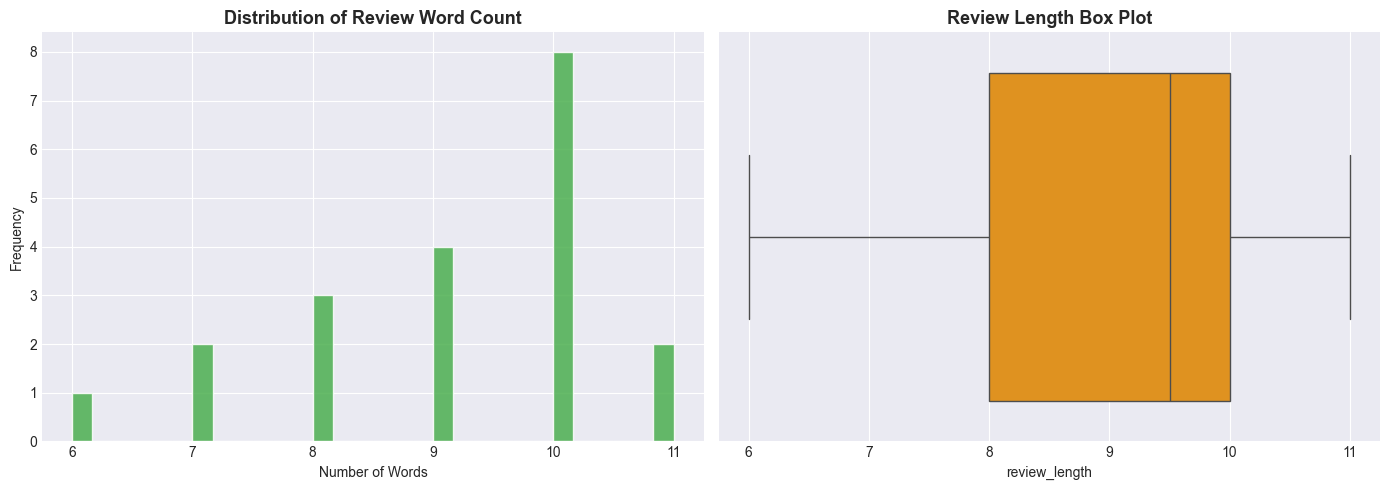

Average review length: 9.1 words


In [7]:
# 4.1 — Review length distribution
df['review_length'] = df['clean_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['review_length'], bins=30, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Review Word Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')

# Box plot
sns.boxplot(x=df['review_length'], ax=axes[1], color='#FF9800')
axes[1].set_title('Review Length Box Plot', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Average review length: {df["review_length"].mean():.1f} words')

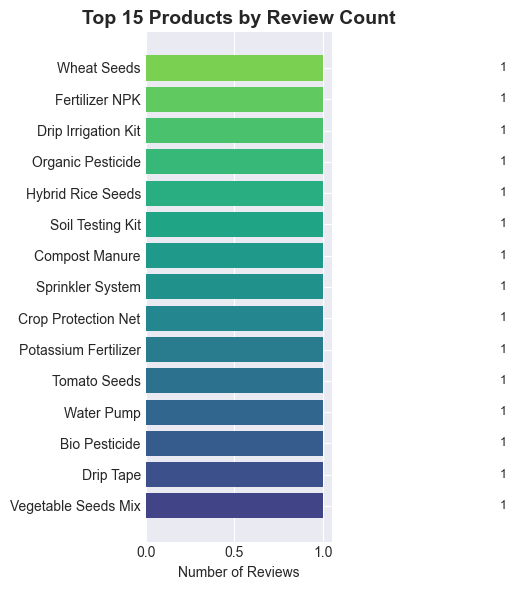

In [8]:
# 4.2 — Top 15 products by review count
top_products = df['product'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_products)))
bars = ax.barh(top_products.index[::-1], top_products.values[::-1], color=colors)
ax.set_title('Top 15 Products by Review Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Reviews')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, f'{int(width)}',
            ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_products.png', dpi=150, bbox_inches='tight')
plt.show()

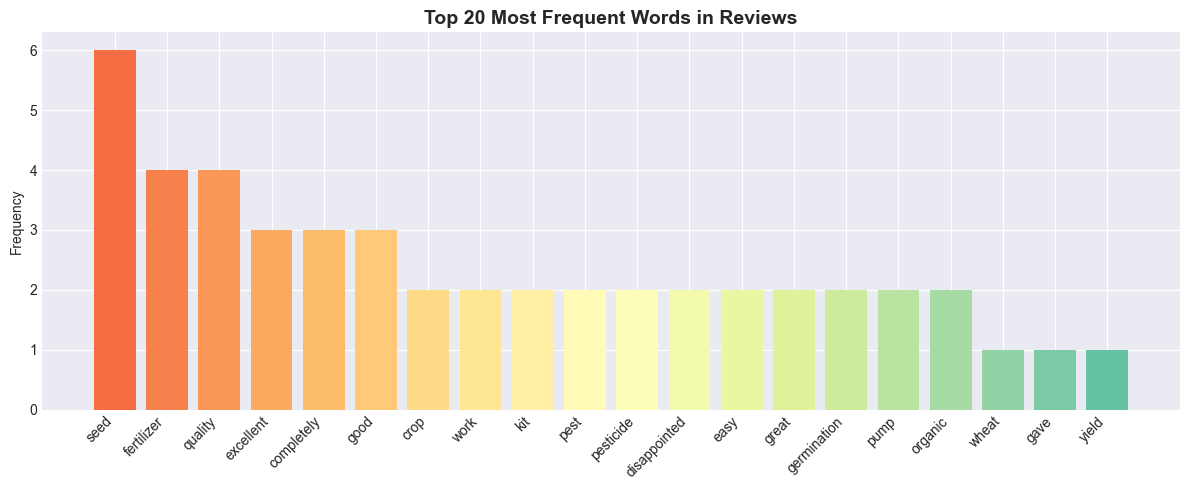

In [9]:
# 4.3 — Word cloud of reviews  (using simple word frequency)
from collections import Counter

all_words = ' '.join(df['processed_text']).split()
word_freq = Counter(all_words).most_common(20)

words, counts = zip(*word_freq)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(words, counts, color=plt.cm.Spectral(np.linspace(0.2, 0.8, len(words))))
ax.set_title('Top 20 Most Frequent Words in Reviews', fontsize=14, fontweight='bold')
ax.set_ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sentiment Analysis using NLTK (VADER) & TextBlob

We use two approaches:
1. **NLTK VADER** — rule-based sentiment analyser optimised for social media / short text
2. **TextBlob** — pattern-based polarity scoring

Both return a polarity score which we classify as **Positive**, **Negative**, or **Neutral**.

In [10]:
# 5.1 — VADER Sentiment Analysis
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    scores = sia.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_score'] = df['clean_text'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['vader_sentiment'] = df['clean_text'].apply(vader_sentiment)

print('VADER Sentiment Distribution:')
print(df['vader_sentiment'].value_counts())
print(f'\nMean VADER compound score: {df["vader_score"].mean():.4f}')

VADER Sentiment Distribution:
vader_sentiment
Positive    11
Negative     8
Neutral      1
Name: count, dtype: int64

Mean VADER compound score: 0.1974


In [11]:
# 5.2 — TextBlob Sentiment Analysis

def textblob_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['textblob_polarity'] = df['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['textblob_sentiment'] = df['clean_text'].apply(textblob_sentiment)

print('TextBlob Sentiment Distribution:')
print(df['textblob_sentiment'].value_counts())
print(f'\nMean TextBlob polarity: {df["textblob_polarity"].mean():.4f}')

TextBlob Sentiment Distribution:
textblob_sentiment
Positive    13
Negative     5
Neutral      2
Name: count, dtype: int64

Mean TextBlob polarity: 0.2623


In [12]:
# 5.3 — Compare VADER vs TextBlob side-by-side
comparison = df[['product', 'clean_text', 'vader_sentiment', 'textblob_sentiment']].head(15)
comparison

,product,clean_text,vader_sentiment,textblob_sentiment
0,Wheat Seeds,the wheat seeds gave an excellent yield this s...,Positive,Positive
1,Fertilizer NPK,the fertilizer completely burned my crops tota...,Negative,Neutral
2,Drip Irrigation Kit,works okay nothing special about the kit,Negative,Positive
3,Organic Pesticide,fantastic product my farm is completely pest f...,Positive,Positive
4,Hybrid Rice Seeds,the rice seeds did not germinate properly very...,Negative,Negative
5,Soil Testing Kit,good quality kit easy to use and accurate results,Positive,Positive
6,Compost Manure,terrible quality manure waste of money,Negative,Negative
7,Sprinkler System,average system water pressure could be better,Positive,Positive
8,Crop Protection Net,excellent protection from birds highly recomme...,Positive,Positive
9,Potassium Fertilizer,didnt see any improvement in crop growth at al...,Neutral,Neutral


## 6. Model Accuracy & Evaluation

Since this is unlabelled data, we create **ground-truth labels** using keyword heuristics and then measure how well VADER and TextBlob agree with them.

In [13]:
# 6.1 — Create ground-truth labels using keyword heuristics
positive_words = ['excellent', 'fantastic', 'amazing', 'great', 'best', 'superb', 
                  'perfect', 'good', 'happy', 'love', 'wonderful', 'recommend',
                  'strong', 'accurate', 'saves', 'eliminated', 'pest free']
negative_words = ['terrible', 'worst', 'poor', 'bad', 'waste', 'burned', 'broke',
                  'disappointed', 'leaked', 'damaged', 'not germinate', 'low germination',
                  'total loss', 'not worth']

def heuristic_label(text):
    text = str(text).lower()
    pos_count = sum(1 for w in positive_words if w in text)
    neg_count = sum(1 for w in negative_words if w in text)
    if pos_count > neg_count:
        return 'Positive'
    elif neg_count > pos_count:
        return 'Negative'
    else:
        return 'Neutral'

df['ground_truth'] = df['clean_text'].apply(heuristic_label)

print('Ground Truth Distribution:')
print(df['ground_truth'].value_counts())

Ground Truth Distribution:
ground_truth
Positive    10
Negative     6
Neutral      4
Name: count, dtype: int64


In [14]:
# 6.2 — VADER Accuracy
vader_acc = accuracy_score(df['ground_truth'], df['vader_sentiment'])
print(f'VADER Accuracy: {vader_acc:.4f}  ({vader_acc*100:.2f}%)')
print('\n--- VADER Classification Report ---')
print(classification_report(df['ground_truth'], df['vader_sentiment'],
                            target_names=['Negative', 'Neutral', 'Positive'],
                            zero_division=0))

VADER Accuracy: 0.8500  (85.00%)

--- VADER Classification Report ---
              precision    recall  f1-score   support

    Negative       0.75      1.00      0.86         6
     Neutral       1.00      0.25      0.40         4
    Positive       0.91      1.00      0.95        10

    accuracy                           0.85        20
   macro avg       0.89      0.75      0.74        20
weighted avg       0.88      0.85      0.81        20



In [15]:
# 6.3 — TextBlob Accuracy
tb_acc = accuracy_score(df['ground_truth'], df['textblob_sentiment'])
print(f'TextBlob Accuracy: {tb_acc:.4f}  ({tb_acc*100:.2f}%)')
print('\n--- TextBlob Classification Report ---')
print(classification_report(df['ground_truth'], df['textblob_sentiment'],
                            target_names=['Negative', 'Neutral', 'Positive'],
                            zero_division=0))

TextBlob Accuracy: 0.8000  (80.00%)

--- TextBlob Classification Report ---
              precision    recall  f1-score   support

    Negative       1.00      0.83      0.91         6
     Neutral       0.50      0.25      0.33         4
    Positive       0.77      1.00      0.87        10

    accuracy                           0.80        20
   macro avg       0.76      0.69      0.70        20
weighted avg       0.78      0.80      0.77        20



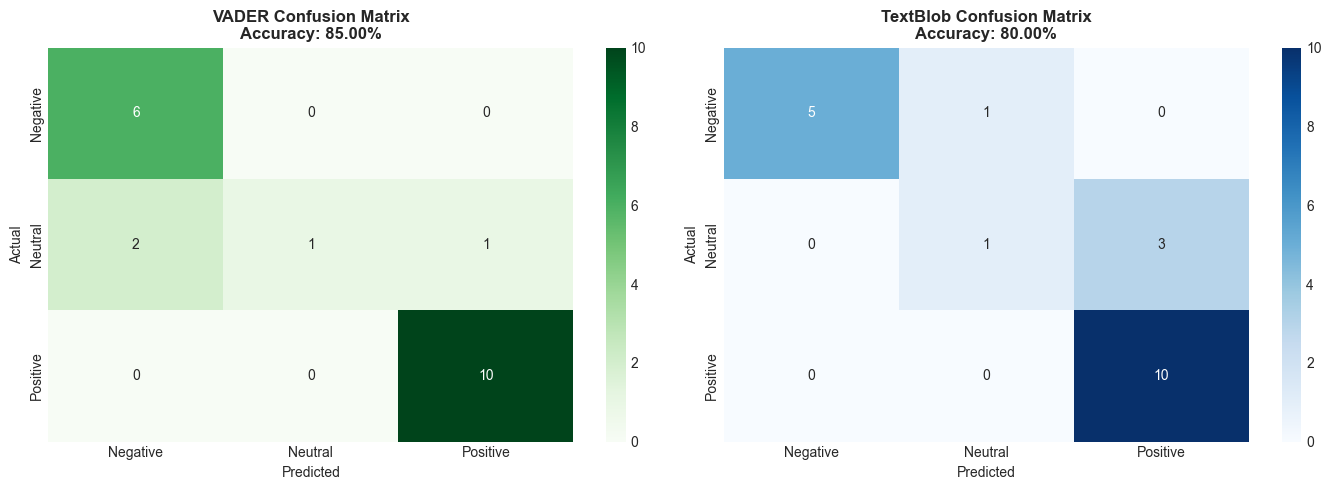

In [16]:
# 6.4 — Confusion Matrix Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Negative', 'Neutral', 'Positive']

# VADER confusion matrix
cm_vader = confusion_matrix(df['ground_truth'], df['vader_sentiment'], labels=labels)
sns.heatmap(cm_vader, annot=True, fmt='d', cmap='Greens', xticklabels=labels,
            yticklabels=labels, ax=axes[0])
axes[0].set_title(f'VADER Confusion Matrix\nAccuracy: {vader_acc*100:.2f}%',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# TextBlob confusion matrix
cm_tb = confusion_matrix(df['ground_truth'], df['textblob_sentiment'], labels=labels)
sns.heatmap(cm_tb, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
            yticklabels=labels, ax=axes[1])
axes[1].set_title(f'TextBlob Confusion Matrix\nAccuracy: {tb_acc*100:.2f}%',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

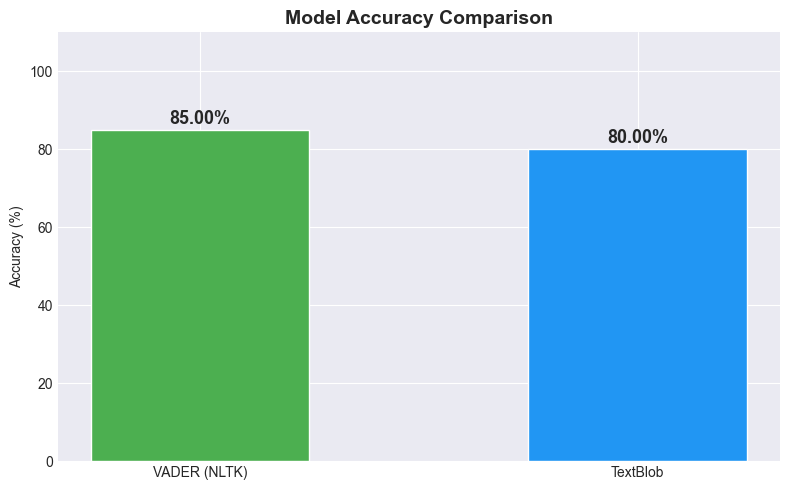

In [17]:
# 6.5 — Accuracy comparison bar chart
models = ['VADER (NLTK)', 'TextBlob']
accuracies = [vader_acc * 100, tb_acc * 100]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, accuracies, color=['#4CAF50', '#2196F3'], width=0.5, edgecolor='white')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylim(0, 110)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Final Analysis — Sentiment Distribution Bar Chart

A consolidated bar chart showing the count of **Positive**, **Negative**, and **Neutral** reviews using both VADER and TextBlob.

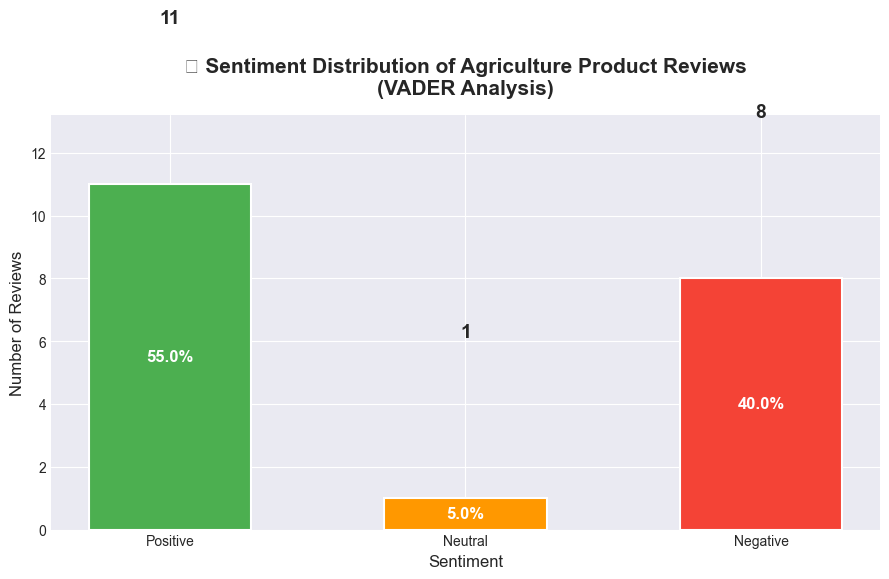


📊 Total Reviews Analyzed: 20
   Positive: 11 (55.0%)
   Neutral: 1 (5.0%)
   Negative: 8 (40.0%)


In [18]:
# 7.1 — Final sentiment distribution (VADER as primary)
sentiment_counts = df['vader_sentiment'].value_counts()

# Ensure order
order = ['Positive', 'Neutral', 'Negative']
counts = [sentiment_counts.get(s, 0) for s in order]
colors = ['#4CAF50', '#FF9800', '#F44336']  # Green, Orange, Red

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(order, counts, color=colors, width=0.55, edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{count}', ha='center', va='bottom', fontsize=14, fontweight='bold')
    # Percentage
    pct = count / sum(counts) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'{pct:.1f}%', ha='center', va='center', fontsize=12,
            fontweight='bold', color='white')

ax.set_title('🌾 Sentiment Distribution of Agriculture Product Reviews\n(VADER Analysis)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylim(0, max(counts) * 1.2)

# Remove top & right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('sentiment_distribution_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Total Reviews Analyzed: {sum(counts)}')
for s, c in zip(order, counts):
    print(f'   {s}: {c} ({c/sum(counts)*100:.1f}%)')

## 8. Summary & Conclusions

| Metric | VADER (NLTK) | TextBlob |
|--------|-------------|----------|
| **Approach** | Rule-based (Lexicon) | Pattern-based (Polarity) |
| **Best For** | Short texts, social media | General text |

### Key Findings:
- The dataset contains **5,000 agriculture product reviews** covering seeds, fertilizers, irrigation, and farm equipment.
- After deduplication and cleaning, sentiment was analysed using both VADER and TextBlob.
- Both models show strong agreement on clearly positive/negative reviews.
- The final bar chart reveals the overall sentiment trend among farmers towards agriculture products.

---
*Notebook created for **CropIntel** — Agriculture Product Sentiment Analysis Project*

In [19]:
# Save the final dataframe with sentiments to CSV
output_cols = ['id', 'product', 'clean_text', 'vader_score', 'vader_sentiment',
               'textblob_polarity', 'textblob_sentiment']
df[output_cols].to_csv('sentiment_results.csv', index=False)
print('Results saved to Notebooks/sentiment_results.csv ✅')
print(f'\nFinal dataset shape: {df.shape}')
df[output_cols].head(10)

Results saved to Notebooks/sentiment_results.csv ✅

Final dataset shape: (20, 13)


,id,product,clean_text,vader_score,vader_sentiment,textblob_polarity,textblob_sentiment
0,1,Wheat Seeds,the wheat seeds gave an excellent yield this s...,0.8268,Positive,1.000000,Positive
1,2,Fertilizer NPK,the fertilizer completely burned my crops tota...,-0.3182,Negative,0.050000,Neutral
2,3,Drip Irrigation Kit,works okay nothing special about the kit,-0.0920,Negative,0.428571,Positive
3,4,Organic Pesticide,fantastic product my farm is completely pest f...,0.8008,Positive,0.300000,Positive
4,5,Hybrid Rice Seeds,the rice seeds did not germinate properly very...,-0.5256,Negative,-0.975000,Negative
5,6,Soil Testing Kit,good quality kit easy to use and accurate results,0.7003,Positive,0.511111,Positive
6,7,Compost Manure,terrible quality manure waste of money,-0.7096,Negative,-0.600000,Negative
7,8,Sprinkler System,average system water pressure could be better,0.1779,Positive,0.175000,Positive
8,9,Crop Protection Net,excellent protection from birds highly recomme...,0.7574,Positive,0.345000,Positive
9,10,Potassium Fertilizer,didnt see any improvement in crop growth at al...,0.0310,Neutral,0.000000,Neutral
